Notebook 4: Compare Results Across Resolutions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


4.1 Loading all Results

In [2]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_BASE = Path('/content/drive/MyDrive/VisionProject')
OUTPUT_DIR = RESULTS_BASE / "comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESOLUTIONS = [64, 128, 224, 384]

summaries = []
for res in RESOLUTIONS:
    summary_path = RESULTS_BASE / f"res_{res}" / "summary.json"
    if not summary_path.exists():
        print(f"WARN: {summary_path} not found, skipping")
        continue
    with open(summary_path) as f:
        s = json.load(f)
    summaries.append(s)

df = pd.DataFrame(summaries)
print(df.to_string(index=False))

 resolution  total_params  model_size_mb  epochs_run  total_train_time_sec  sec_per_epoch  inference_ms_per_image  best_val_accuracy  test_accuracy  macro_f1  macro_precision  macro_recall
         64       2284885           8.72          15                 384.4           25.6                  336.95             0.3520         0.3281    0.3024           0.3258        0.3235
        128       2284885           8.72          15                 421.9           28.1                  383.82             0.4592         0.4792    0.4429           0.4699        0.4801
        224       2284885           8.72          15                  73.1            4.9                   14.05             0.4796         0.5260    0.4899           0.4826        0.5227
        384       2284885           8.72          15                  85.4            5.7                   17.38             0.5102         0.5156    0.4852           0.4813        0.5177


4.2 Headline Comparison Table

In [3]:
# Select the key columns for the report
report_table = df[[
    "resolution", "test_accuracy", "macro_f1",
    "sec_per_epoch", "inference_ms_per_image"
]].copy()
report_table.columns = ["Resolution", "Test Accuracy", "Macro F1",
                        "Sec/Epoch", "Inference (ms/image)"]

print(report_table.to_string(index=False))
report_table.to_csv(OUTPUT_DIR / "headline_comparison.csv", index=False)

 Resolution  Test Accuracy  Macro F1  Sec/Epoch  Inference (ms/image)
         64         0.3281    0.3024       25.6                336.95
        128         0.4792    0.4429       28.1                383.82
        224         0.5260    0.4899        4.9                 14.05
        384         0.5156    0.4852        5.7                 17.38


4.3 Accuracy vs Resolution

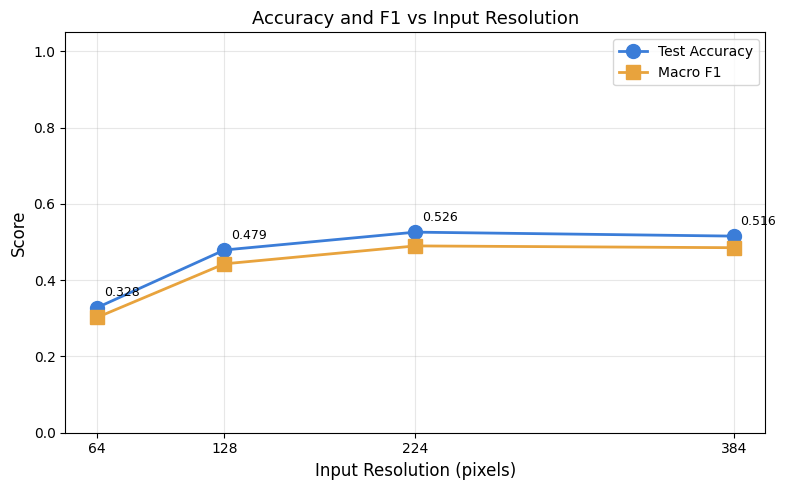

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["resolution"], df["test_accuracy"], "o-", linewidth=2, markersize=10,
        color="#3b7dd8", label="Test Accuracy")
ax.plot(df["resolution"], df["macro_f1"], "s-", linewidth=2, markersize=10,
        color="#e8a33d", label="Macro F1")
ax.set_xlabel("Input Resolution (pixels)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Accuracy and F1 vs Input Resolution", fontsize=13)
ax.set_xticks(df["resolution"])
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

# Annotate each point
for _, row in df.iterrows():
    ax.annotate(f"{row['test_accuracy']:.3f}",
                xy=(row["resolution"], row["test_accuracy"]),
                xytext=(5, 8), textcoords="offset points", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_vs_resolution.png", dpi=120, bbox_inches="tight")
plt.show()

4.4 Training Time and Inference Time vs Resolution

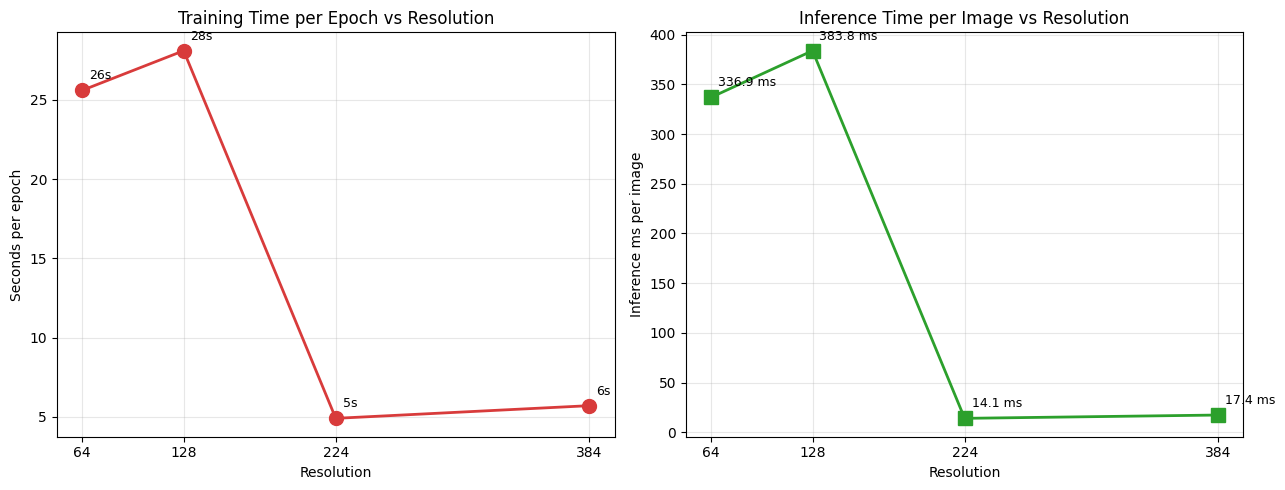

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Training time
axes[0].plot(df["resolution"], df["sec_per_epoch"], "o-", linewidth=2,
             markersize=10, color="#d83b3b")
axes[0].set_xlabel("Resolution"); axes[0].set_ylabel("Seconds per epoch")
axes[0].set_title("Training Time per Epoch vs Resolution")
axes[0].set_xticks(df["resolution"])
axes[0].grid(alpha=0.3)
for _, row in df.iterrows():
    axes[0].annotate(f"{row['sec_per_epoch']:.0f}s",
                     xy=(row["resolution"], row["sec_per_epoch"]),
                     xytext=(5, 8), textcoords="offset points", fontsize=9)

# Inference time
axes[1].plot(df["resolution"], df["inference_ms_per_image"], "s-", linewidth=2,
             markersize=10, color="#2ca02c")
axes[1].set_xlabel("Resolution"); axes[1].set_ylabel("Inference ms per image")
axes[1].set_title("Inference Time per Image vs Resolution")
axes[1].set_xticks(df["resolution"])
axes[1].grid(alpha=0.3)
for _, row in df.iterrows():
    axes[1].annotate(f"{row['inference_ms_per_image']:.1f} ms",
                     xy=(row["resolution"], row["inference_ms_per_image"]),
                     xytext=(5, 8), textcoords="offset points", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "time_vs_resolution.png", dpi=120, bbox_inches="tight")
plt.show()

4.5 Accuracy vs Compute Trade-off Plot

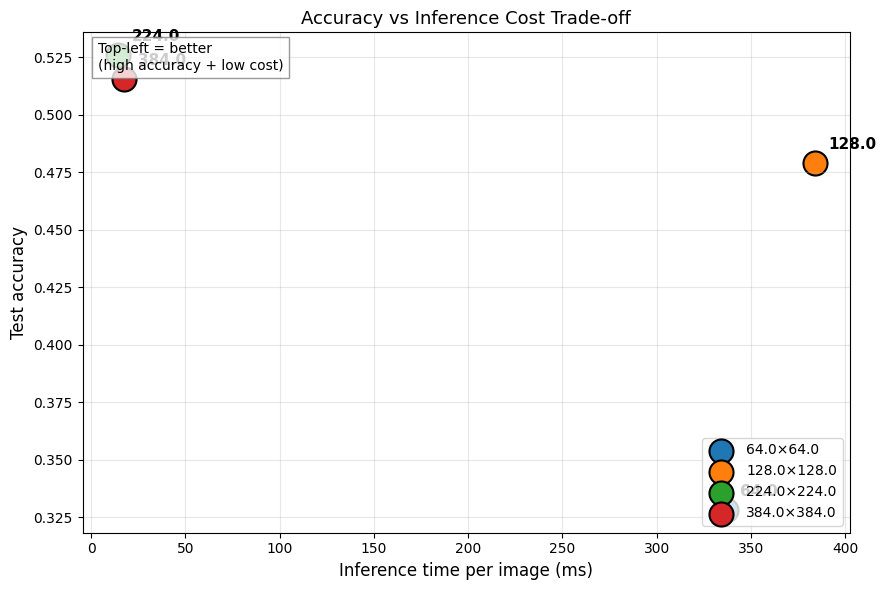

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter, color-coded by resolution
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for i, (_, row) in enumerate(df.iterrows()):
    ax.scatter(row["inference_ms_per_image"], row["test_accuracy"],
               s=300, color=colors[i % len(colors)], edgecolors="black", linewidths=1.5,
               label=f"{row['resolution']}×{row['resolution']}")
    ax.annotate(f"{row['resolution']}",
                xy=(row["inference_ms_per_image"], row["test_accuracy"]),
                xytext=(10, 10), textcoords="offset points", fontsize=11, fontweight="bold")

ax.set_xlabel("Inference time per image (ms)", fontsize=12)
ax.set_ylabel("Test accuracy", fontsize=12)
ax.set_title("Accuracy vs Inference Cost Trade-off", fontsize=13)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")

# Note about ideal direction
ax.text(0.02, 0.98, "Top-left = better\n(high accuracy + low cost)",
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_vs_cost.png", dpi=120, bbox_inches="tight")
plt.show()

4.6 Per-Class F1 At Each Resolution

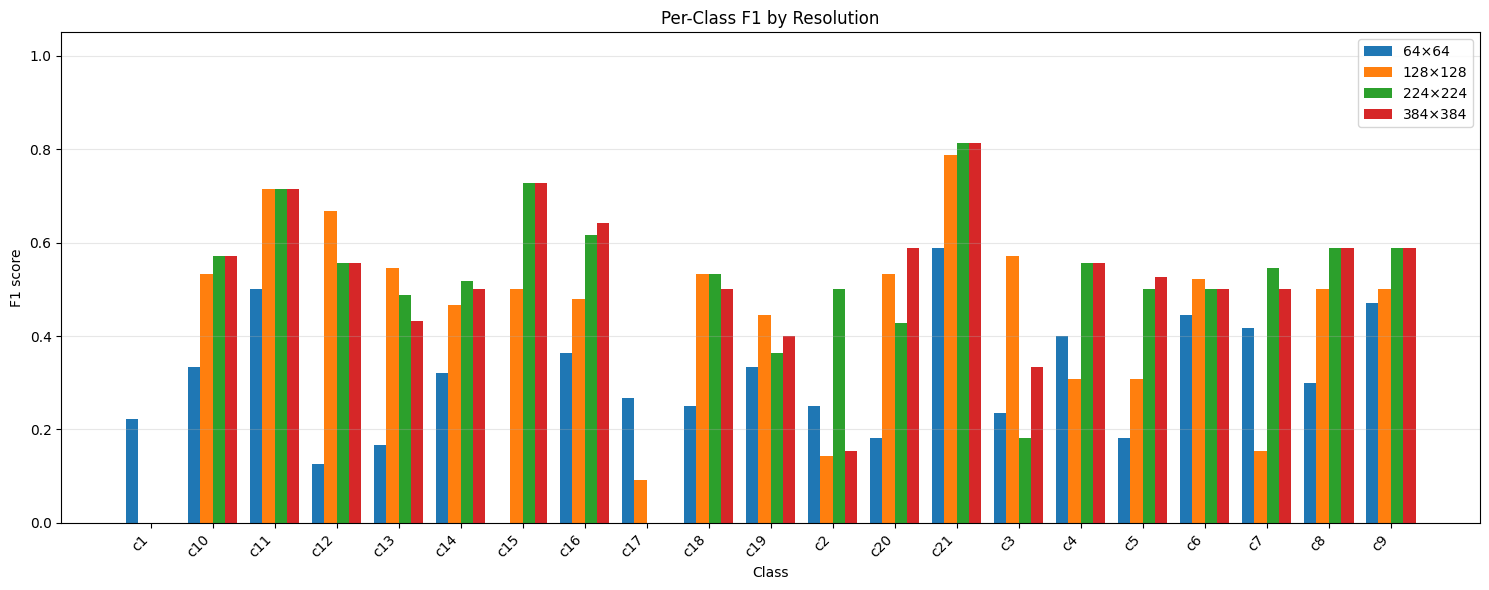

In [7]:
# Load per-class metrics for each resolution
per_class_data = {}
for res in RESOLUTIONS:
    pc_path = RESULTS_BASE / f"res_{res}" / "per_class_metrics.csv"
    if not pc_path.exists():
        continue
    pc_df = pd.read_csv(pc_path)
    per_class_data[res] = pc_df

# Combine into one big chart
if per_class_data:
    classes = per_class_data[RESOLUTIONS[0]]["class"].tolist()
    fig, ax = plt.subplots(figsize=(15, 6))

    width = 0.2
    x = np.arange(len(classes))
    for i, res in enumerate(per_class_data.keys()):
        pc_df = per_class_data[res]
        offsets = x + (i - 1.5) * width
        ax.bar(offsets, pc_df["f1"], width, label=f"{res}×{res}", color=colors[i % len(colors)])

    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("class", "c") for c in classes], rotation=45, ha="right")
    ax.set_ylabel("F1 score")
    ax.set_xlabel("Class")
    ax.set_title("Per-Class F1 by Resolution")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "per_class_f1_by_resolution.png", dpi=120, bbox_inches="tight")
    plt.show()

4.7 Interpretation Helper

In [8]:
# Find the sweet spot
sorted_by_acc = df.sort_values("test_accuracy", ascending=False)
best_acc = sorted_by_acc.iloc[0]

# Find smallest resolution within 2 pp of best
within_2pp = df[df["test_accuracy"] >= best_acc["test_accuracy"] - 0.02]
smallest_acceptable = within_2pp.sort_values("resolution").iloc[0]

print(f"=== INTERPRETATION ===\n")
print(f"Best accuracy: {best_acc['test_accuracy']:.3f} at {best_acc['resolution']}x{best_acc['resolution']}")
print(f"Smallest resolution within 2 pp of best: {smallest_acceptable['resolution']}x{smallest_acceptable['resolution']}")
print(f"  Accuracy at that resolution: {smallest_acceptable['test_accuracy']:.3f}")
print(f"  Inference speedup vs best: {best_acc['inference_ms_per_image']/smallest_acceptable['inference_ms_per_image']:.2f}x")
print()
print("DEPLOYMENT IMPLICATION:")
if smallest_acceptable["resolution"] < best_acc["resolution"]:
    print(f"  Using {smallest_acceptable['resolution']}x{smallest_acceptable['resolution']} instead of {best_acc['resolution']}x{best_acc['resolution']}")
    print(f"  costs only {(best_acc['test_accuracy'] - smallest_acceptable['test_accuracy'])*100:.1f} pp of accuracy")
    print(f"  but saves {(1 - smallest_acceptable['inference_ms_per_image']/best_acc['inference_ms_per_image'])*100:.0f}% inference time.")
else:
    print(f"  Best accuracy requires the maximum resolution tested. No savings possible.")
print()
print("All comparison outputs saved to:", OUTPUT_DIR)

=== INTERPRETATION ===

Best accuracy: 0.526 at 224.0x224.0
Smallest resolution within 2 pp of best: 224.0x224.0
  Accuracy at that resolution: 0.526
  Inference speedup vs best: 1.00x

DEPLOYMENT IMPLICATION:
  Best accuracy requires the maximum resolution tested. No savings possible.

All comparison outputs saved to: /content/drive/MyDrive/VisionProject/comparison
